In [14]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

In [15]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 100
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [16]:
keras.backend.clear_session(free_memory=True)
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img',
image_size=(300, 300),
subset='both',
batch_size=BATCH_SIZE,
validation_split=0.2,
seed=42)

Found 4240 files belonging to 8 classes.
Using 3392 files for training.
Using 848 files for validation.


In [17]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [19]:
incv3 = keras.applications.InceptionV3(weights=None,include_top=False,input_shape=(300,300,3))
model = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  # layers.Resizing(299,299),
#   tf.keras.layers.Lambda(tf.image.grayscale_to_rgb),
  incv3,
  # layers.GlobalAveragePooling2D(name='gp'),
  layers.Flatten(),
  layers.Dense((1024),activation='relu'),
  layers.Dense((512),activation='relu'),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │   134,218,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,550,440 (597.19 MB)

 Trainable params: 156,516,008 (597.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [21]:
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [22]:
keras.backend.clear_session(free_memory=True)
history = model.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_sparse_categorical_accuracy",
            patience=EPOCHS/10,
            restore_best_weights=True,
        )]
        )

Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - loss: 8.7665 - sparse_categorical_accuracy: 0.1960 - val_loss: 8.0438 - val_sparse_categorical_accuracy: 0.1995
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 1.4440 - sparse_categorical_accuracy: 0.4888 - val_loss: 2.8197 - val_sparse_categorical_accuracy: 0.3173
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.8931 - sparse_categorical_accuracy: 0.6642 - val_loss: 1.0624 - val_sparse_categorical_accuracy: 0.6394
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.6694 - sparse_categorical_accuracy: 0.7574 - val_loss: 0.7109 - val_sparse_categorical_accuracy: 0.7524
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.6058 - sparse_categorical_accuracy: 0.7901 - val_loss: 0.5557 - val_sparse_categorical_accuracy: 0.8221
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.5798 - sparse_categorical_accuracy: 0.7866 - val_loss: 0.8631 - val_sparse_categorical_accurac

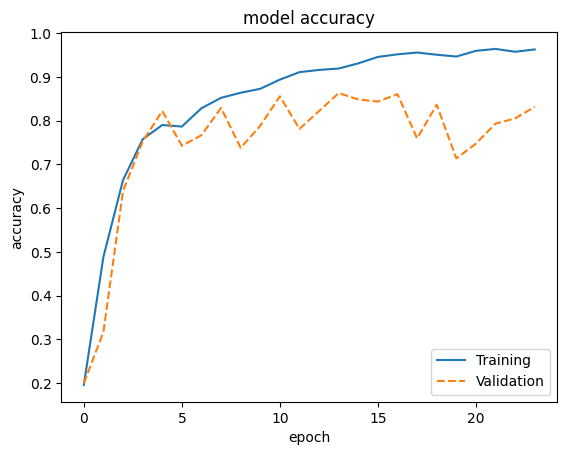

In [23]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [24]:
model.evaluate(test_ds)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.5894 - sparse_categorical_accuracy: 0.8449


[0.5894425511360168, 0.8449074029922485]